In [4]:
import os
print(os.listdir('/kaggle/input'))
print(os.listdir('/kaggle/input/datasets/jainam2511j/pneumonia-dataset'))

['datasets']
['chest_xray']


In [5]:
dataset_path = "/kaggle/input/datasets/jainam2511j/pneumonia-dataset/chest_xray/chest_xray"

print(os.listdir(dataset_path))

['val', 'test', 'train']


In [6]:
for folder in os.listdir(dataset_path):
    print(folder, "-->", os.listdir(os.path.join(dataset_path, folder)))

val --> ['PNEUMONIA', 'NORMAL']
test --> ['PNEUMONIA', 'NORMAL']
train --> ['PNEUMONIA', 'NORMAL']


In [7]:
for split in os.listdir(dataset_path):
    
    split_path = os.path.join(dataset_path, split)
    
    print(f"\n{split.upper()} DATASET")
    
    for category in os.listdir(split_path):
        
        category_path = os.path.join(split_path, category)
        
        total_images = len(os.listdir(category_path))
        
        print(f"{category} : {total_images}")


VAL DATASET
PNEUMONIA : 8
NORMAL : 8

TEST DATASET
PNEUMONIA : 390
NORMAL : 234

TRAIN DATASET
PNEUMONIA : 3875
NORMAL : 1341


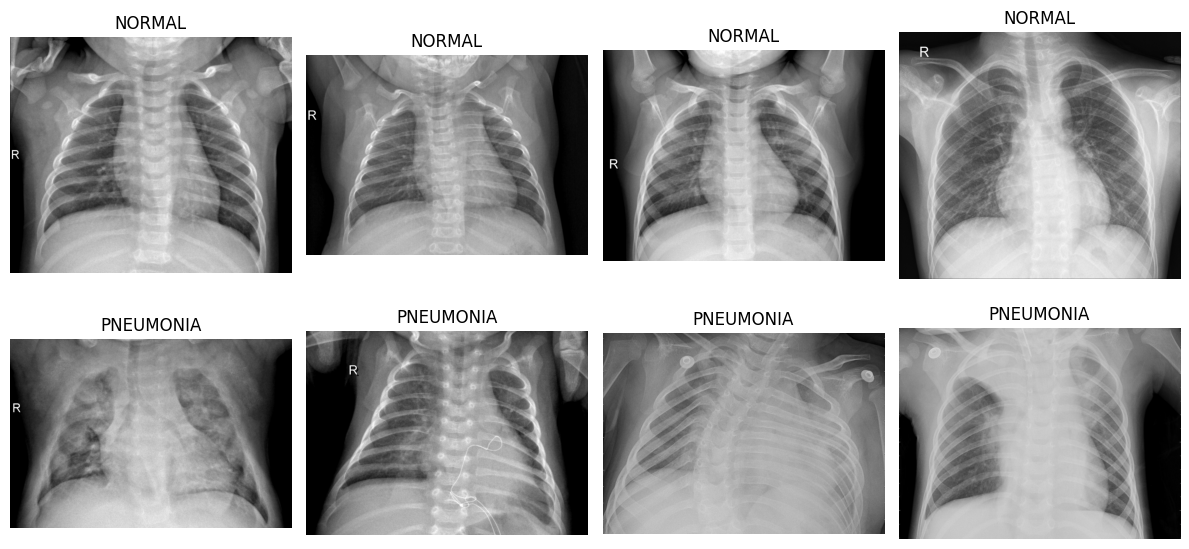

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

# Paths
normal_path = os.path.join(dataset_path, 'train', 'NORMAL')
pneumonia_path = os.path.join(dataset_path, 'train', 'PNEUMONIA')

# Random images
normal_images = random.sample(os.listdir(normal_path), 4)
pneumonia_images = random.sample(os.listdir(pneumonia_path), 4)

# Plot
plt.figure(figsize=(12,6))

# NORMAL Images
for i, image_name in enumerate(normal_images):
    
    image_path = os.path.join(normal_path, image_name)
    image = mpimg.imread(image_path)
    
    plt.subplot(2,4,i+1)
    plt.imshow(image, cmap='gray')
    plt.title("NORMAL")
    plt.axis('off')

# PNEUMONIA Images
for i, image_name in enumerate(pneumonia_images):
    
    image_path = os.path.join(pneumonia_path, image_name)
    image = mpimg.imread(image_path)
    
    plt.subplot(2,4,i+5)
    plt.imshow(image, cmap='gray')
    plt.title("PNEUMONIA")
    plt.axis('off')

plt.tight_layout()
plt.show()

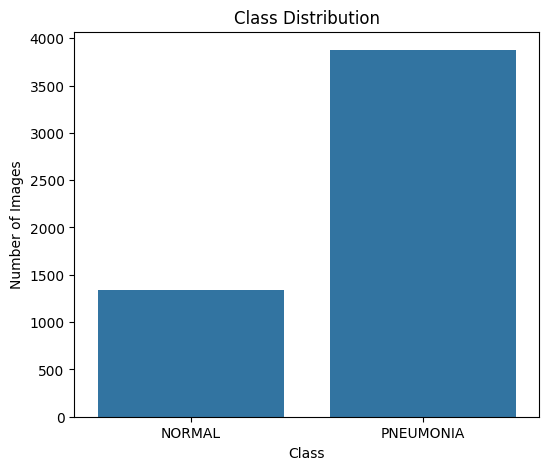

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Image counts
categories = ['NORMAL', 'PNEUMONIA']
counts = [1341, 3875]

# Plot
plt.figure(figsize=(6,5))

sns.barplot(x=categories, y=counts)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

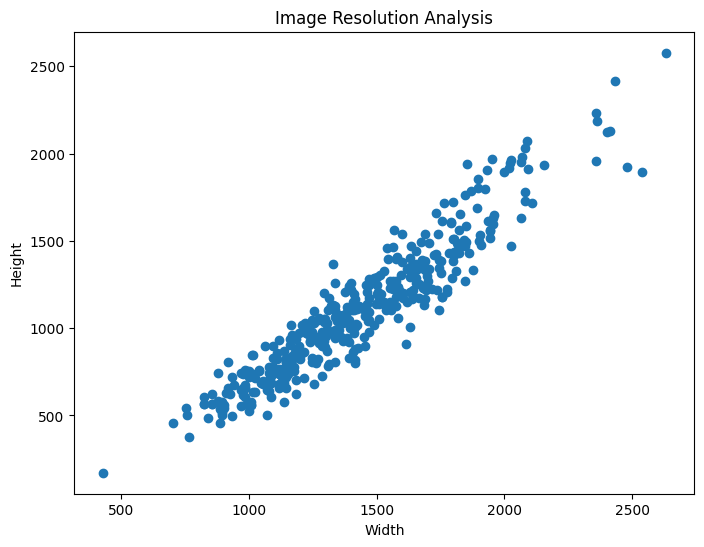

In [10]:
from PIL import Image
import os
import matplotlib.pyplot as plt

# Store dimensions
widths = []
heights = []

# Use training folder
train_path = os.path.join(dataset_path, 'train')

# Read images
for category in os.listdir(train_path):
    
    category_path = os.path.join(train_path, category)
    
    for image_name in os.listdir(category_path)[:200]:
        
        image_path = os.path.join(category_path, image_name)
        
        try:
            img = Image.open(image_path)
            width, height = img.size
            
            widths.append(width)
            heights.append(height)
            
        except:
            pass

# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(widths, heights)

plt.title("Image Resolution Analysis")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

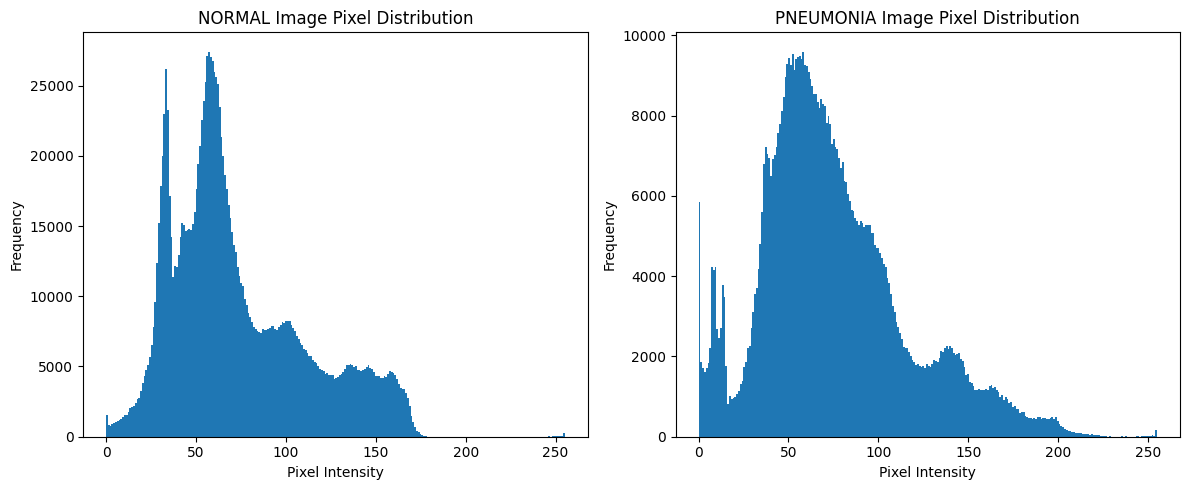

In [11]:
import cv2
import matplotlib.pyplot as plt
import os

# Sample image paths
normal_image_path = os.path.join(dataset_path, 'train', 'NORMAL',
                                 os.listdir(os.path.join(dataset_path, 'train', 'NORMAL'))[0])

pneumonia_image_path = os.path.join(dataset_path, 'train', 'PNEUMONIA',
                                    os.listdir(os.path.join(dataset_path, 'train', 'PNEUMONIA'))[0])

# Read images in grayscale
normal_img = cv2.imread(normal_image_path, cv2.IMREAD_GRAYSCALE)
pneumonia_img = cv2.imread(pneumonia_image_path, cv2.IMREAD_GRAYSCALE)

# Plot histograms
plt.figure(figsize=(12,5))

# NORMAL Histogram
plt.subplot(1,2,1)
plt.hist(normal_img.ravel(), bins=256)
plt.title("NORMAL Image Pixel Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

# PNEUMONIA Histogram
plt.subplot(1,2,2)
plt.hist(pneumonia_img.ravel(), bins=256)
plt.title("PNEUMONIA Image Pixel Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

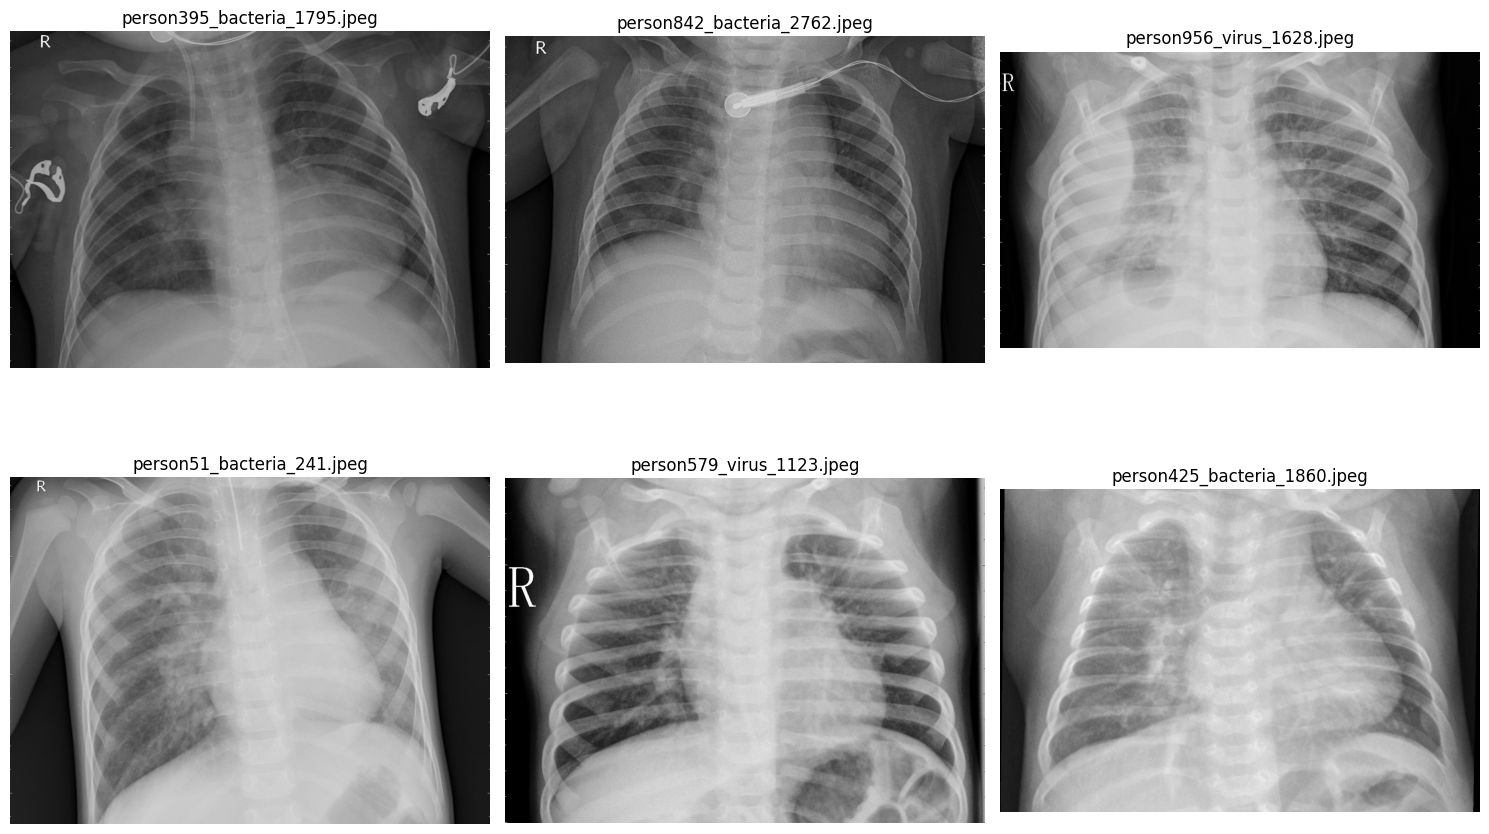

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

# Pneumonia image folder
pneumonia_path = os.path.join(dataset_path, 'train', 'PNEUMONIA')

# Random 6 images
random_images = random.sample(os.listdir(pneumonia_path), 6)

# Plot
plt.figure(figsize=(15,10))

for i, image_name in enumerate(random_images):
    
    image_path = os.path.join(pneumonia_path, image_name)
    
    image = mpimg.imread(image_path)
    
    plt.subplot(2,3,i+1)
    plt.imshow(image, cmap='gray')
    plt.title(image_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# EDA Conclusion

1. The dataset contains two classes:
   - NORMAL
   - PNEUMONIA

2. The dataset is imbalanced:
   - Pneumonia images are significantly higher than normal images.

3. X-ray image resolutions are inconsistent:
   - Different widths and heights are observed.
   - Image resizing will be required before model training.

4. Pixel intensity distributions differ between classes:
   - Pneumonia images show brighter and denser regions due to lung opacities.

5. Structural artifacts are present:
   - R/L markers
   - medical devices
   - brightness variations
   These may introduce shortcut learning in deep learning models.

6. Data preprocessing and augmentation will be necessary before CNN training.